# NHS A&E Admissions Analysis - May & June 2026

Analysis of NHS England's A&E Attendances and Emergency Admissions data, comparing 
May and June 2026 across 192 NHS Trusts. Covers data cleaning, derived performance 
metrics, statistical analysis, and a month-over-month comparison.

## 1. Setup and Imports

Importing pandas, matplotlib, and numpy for data handling, calculation, and visualization.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

## 2. June 2026 — Load and Inspect Data

Loading the June 2026 monthly A&E dataset and performing an initial inspection: 
shape, missing values, and column definitions.

In [2]:
ae_jun2026_df = pd.read_csv(filepath_or_buffer='June-2026-CSV-Wfg38l.csv')
ae_jun2026_df

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Attendances over 4hrs Other Department,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions
0,MSitAE-JUNE-2026,RYY,NHS ENGLAND SOUTH EAST,KENT COMMUNITY HEALTH NHS FOUNDATION TRUST,0,0,6625,0,0,0,...,43,0,0,0,0,0,0,0,0,0
1,MSitAE-JUNE-2026,AQN04,NHS ENGLAND SOUTH EAST,PHL LYMINGTON UTC,0,0,3396,0,0,10,...,81,0,0,0,0,0,0,0,0,0
2,MSitAE-JUNE-2026,C82009,NHS ENGLAND MIDLANDS,MARKET HARBOROUGH MED.CTR,0,0,307,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,MSitAE-JUNE-2026,C82038,NHS ENGLAND MIDLANDS,LATHAM HOUSE MEDICAL PRACTICE,0,0,441,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,MSitAE-JUNE-2026,NDJ,NHS ENGLAND SOUTH EAST,FIRST COMMUNITY HEALTH AND CARE CIC,0,0,2562,0,0,0,...,60,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,MSitAE-JUNE-2026,RBL,NHS ENGLAND NORTH WEST,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,8388,0,2737,0,0,175,...,40,0,0,4,374,705,2250,0,0,1824
189,MSitAE-JUNE-2026,RJ2,NHS ENGLAND LONDON,LEWISHAM AND GREENWICH NHS TRUST,16456,0,18040,0,0,860,...,423,0,0,9,1095,582,4811,0,0,538
190,MSitAE-JUNE-2026,RM3,NHS ENGLAND NORTH WEST,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,27750,0,9330,0,0,0,...,397,0,0,0,958,1231,7651,0,361,2628
191,MSitAE-JUNE-2026,NTPAD,NHS ENGLAND SOUTH EAST,PRACTICE PLUS GROUP SURGICAL CENTRE - ST MARYS...,0,0,5421,0,0,265,...,149,0,0,5,0,0,0,0,0,0


In [3]:
ae_jun2026_df.shape

(193, 22)

In [4]:
ae_jun2026_df.isna().sum()

Period                                                        0
Org Code                                                      0
Parent Org                                                    0
Org name                                                      0
A&E attendances Type 1                                        0
A&E attendances Type 2                                        0
A&E attendances Other A&E Department                          0
A&E attendances Booked Appointments Type 1                    0
A&E attendances Booked Appointments Type 2                    0
A&E attendances Booked Appointments Other Department          0
Attendances over 4hrs Type 1                                  0
Attendances over 4hrs Type 2                                  0
Attendances over 4hrs Other Department                        0
Attendances over 4hrs Booked Appointments Type 1              0
Attendances over 4hrs Booked Appointments Type 2              0
Attendances over 4hrs Booked Appointment

In [5]:
ae_jun2026_df.columns

Index(['Period', 'Org Code', 'Parent Org', 'Org name',
       'A&E attendances Type 1', 'A&E attendances Type 2',
       'A&E attendances Other A&E Department',
       'A&E attendances Booked Appointments Type 1',
       'A&E attendances Booked Appointments Type 2',
       'A&E attendances Booked Appointments Other Department',
       'Attendances over 4hrs Type 1', 'Attendances over 4hrs Type 2',
       'Attendances over 4hrs Other Department',
       'Attendances over 4hrs Booked Appointments Type 1',
       'Attendances over 4hrs Booked Appointments Type 2',
       'Attendances over 4hrs Booked Appointments Other Department',
       'Patients who have waited 4-12 hs from DTA to admission',
       'Patients who have waited 12+ hrs from DTA to admission',
       'Emergency admissions via A&E - Type 1',
       'Emergency admissions via A&E - Type 2',
       'Emergency admissions via A&E - Other A&E department',
       'Other emergency admissions'],
      dtype='object')

In [6]:
ae_jun2026_df.head()

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Attendances over 4hrs Other Department,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions
0,MSitAE-JUNE-2026,RYY,NHS ENGLAND SOUTH EAST,KENT COMMUNITY HEALTH NHS FOUNDATION TRUST,0,0,6625,0,0,0,...,43,0,0,0,0,0,0,0,0,0
1,MSitAE-JUNE-2026,AQN04,NHS ENGLAND SOUTH EAST,PHL LYMINGTON UTC,0,0,3396,0,0,10,...,81,0,0,0,0,0,0,0,0,0
2,MSitAE-JUNE-2026,C82009,NHS ENGLAND MIDLANDS,MARKET HARBOROUGH MED.CTR,0,0,307,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,MSitAE-JUNE-2026,C82038,NHS ENGLAND MIDLANDS,LATHAM HOUSE MEDICAL PRACTICE,0,0,441,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,MSitAE-JUNE-2026,NDJ,NHS ENGLAND SOUTH EAST,FIRST COMMUNITY HEALTH AND CARE CIC,0,0,2562,0,0,0,...,60,0,0,0,0,0,0,0,0,0


## 3. June 2026 — Data Cleaning

Removing a hidden "Total" summary row found mixed into the real Trust-level data, 
to avoid double-counting in any later aggregation.

In [7]:
ae_jun2026_df[ae_jun2026_df['Org Code'] == 'Total']

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Attendances over 4hrs Other Department,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions
192,Total,Total,Total,Total,1461113,54348,846810,27489,542,47604,...,29400,7576,30,527,77353,49466,390733,1431,5790,136799


In [8]:
ae_jun2026_clean_df = (ae_jun2026_df[ae_jun2026_df['Org Code'] != 'Total']).copy()

In [9]:
ae_jun2026_clean_df.shape

(192, 22)

## 4. June 2026 — Derived Metrics

Calculating total attendances (unplanned, booked, combined), total emergency 
admissions, and admission rate (%) per Trust.

In [10]:
ae_jun2026_clean_df['total_attendances'] = (ae_jun2026_clean_df['A&E attendances Type 1'] +
                                     ae_jun2026_clean_df['A&E attendances Type 2'] +
                                     ae_jun2026_clean_df['A&E attendances Other A&E Department'] +
                                     ae_jun2026_clean_df['A&E attendances Booked Appointments Type 1'] +
                                     ae_jun2026_clean_df['A&E attendances Booked Appointments Type 2'] +
                                     ae_jun2026_clean_df['A&E attendances Booked Appointments Other Department'])

In [11]:
ae_jun2026_clean_df[['Org name','total_attendances']].sort_values('total_attendances',ascending=False).head(10)

,Org name,total_attendances
107,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,48715
88,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,48305
171,BARTS HEALTH NHS TRUST,46420
91,ROYAL FREE LONDON NHS FOUNDATION TRUST,44998
190,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,37080
90,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,36173
189,LEWISHAM AND GREENWICH NHS TRUST,35356
20,FRIMLEY HEALTH NHS FOUNDATION TRUST,35159
62,UNIVERSITY HOSPITALS OF DERBY AND BURTON NHS F...,33828
40,UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST,33640


In [12]:
ae_jun2026_clean_df['total_emergency_admissions'] = (ae_jun2026_clean_df['Emergency admissions via A&E - Type 1'] +
                                                                  ae_jun2026_clean_df['Emergency admissions via A&E - Type 2'] +
                                                                  ae_jun2026_clean_df['Emergency admissions via A&E - Other A&E department'])
                                                    

In [13]:
ae_jun2026_clean_df['admission_rate_pct'] = round((ae_jun2026_clean_df['total_emergency_admissions'] /
                                                 ae_jun2026_clean_df['total_attendances'])*100,2)

In [14]:
ae_jun2026_clean_df.head()

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions,total_attendances,total_emergency_admissions,admission_rate_pct
0,MSitAE-JUNE-2026,RYY,NHS ENGLAND SOUTH EAST,KENT COMMUNITY HEALTH NHS FOUNDATION TRUST,0,0,6625,0,0,0,...,0,0,0,0,0,0,0,6625,0,0.0
1,MSitAE-JUNE-2026,AQN04,NHS ENGLAND SOUTH EAST,PHL LYMINGTON UTC,0,0,3396,0,0,10,...,0,0,0,0,0,0,0,3406,0,0.0
2,MSitAE-JUNE-2026,C82009,NHS ENGLAND MIDLANDS,MARKET HARBOROUGH MED.CTR,0,0,307,0,0,0,...,0,0,0,0,0,0,0,307,0,0.0
3,MSitAE-JUNE-2026,C82038,NHS ENGLAND MIDLANDS,LATHAM HOUSE MEDICAL PRACTICE,0,0,441,0,0,0,...,0,0,0,0,0,0,0,441,0,0.0
4,MSitAE-JUNE-2026,NDJ,NHS ENGLAND SOUTH EAST,FIRST COMMUNITY HEALTH AND CARE CIC,0,0,2562,0,0,0,...,0,0,0,0,0,0,0,2562,0,0.0


## 5. June 2026 — Handling Infinite Values

A small number of Trusts returned an infinite admission rate due to zero recorded 
attendances alongside non-zero admissions. These were traced to community/mental 
health Trusts without standard A&E departments, and replaced with NaN.

In [15]:
ae_jun2026_clean_df[['Org name','total_attendances','total_emergency_admissions','admission_rate_pct']].sort_values(
    'admission_rate_pct',ascending=False).head()

,Org name,total_attendances,total_emergency_admissions,admission_rate_pct
21,DORSET HEALTHCARE UNIVERSITY NHS FOUNDATION TRUST,0,1,inf
11,CORNWALL PARTNERSHIP NHS FOUNDATION TRUST,0,15,inf
166,COVENTRY AND WARWICKSHIRE PARTNERSHIP NHS TRUST,0,3,inf
42,BARNSLEY HOSPITAL NHS FOUNDATION TRUST,10151,3532,34.79
129,MERSEY AND WEST LANCASHIRE TEACHING HOSPITALS ...,25424,8042,31.63


In [16]:
ae_jun2026_clean_df['admission_rate_pct'].isna().sum()

np.int64(6)

In [17]:
ae_jun2026_clean_df['admission_rate_pct'] = ae_jun2026_clean_df['admission_rate_pct'].replace(to_replace=[np.inf,-np.inf],value=np.nan)

In [18]:
ae_jun2026_clean_df['admission_rate_pct'].isna().sum()

np.int64(9)

In [19]:
ae_jun2026_clean_df[['Org name','total_attendances','total_emergency_admissions','admission_rate_pct']].sort_values(
    'admission_rate_pct',ascending=False).head()

,Org name,total_attendances,total_emergency_admissions,admission_rate_pct
42,BARNSLEY HOSPITAL NHS FOUNDATION TRUST,10151,3532,34.79
129,MERSEY AND WEST LANCASHIRE TEACHING HOSPITALS ...,25424,8042,31.63
111,NORTH BRISTOL NHS TRUST,9801,3053,31.15
63,SURREY AND SUSSEX HEALTHCARE NHS TRUST,10249,3157,30.80
93,WALSALL HEALTHCARE NHS TRUST,14543,4460,30.67


In [20]:
ae_jun2026_clean_df[['Org name','total_attendances','total_emergency_admissions','admission_rate_pct']].sort_values(
    'admission_rate_pct',ascending=False).tail(71)

,Org name,total_attendances,total_emergency_admissions,admission_rate_pct
75,UNIVERSITY HOSPITALS COVENTRY AND WARWICKSHIRE...,21819,922,4.23
178,BERKSHIRE HEALTHCARE NHS FOUNDATION TRUST,1604,42,2.62
105,QUEEN VICTORIA HOSPITAL NHS FOUNDATION TRUST,1478,3,0.20
78,MOORFIELDS EYE HOSPITAL NHS FOUNDATION TRUST,6415,6,0.09
47,FAVERSHAM MEDICAL PRACTICE MIU,2781,0,0.00
...,...,...,...,...
65,SOUTH WEST YORKSHIRE PARTNERSHIP NHS FOUNDATIO...,0,0,NaN
68,THE CHRISTIE NHS FOUNDATION TRUST,0,0,NaN
99,THE WALTON CENTRE NHS FOUNDATION TRUST,0,0,NaN
142,THE ROBERT JONES AND AGNES HUNT ORTHOPAEDIC HO...,0,0,NaN


## 6. June 2026 — Breach Rate Metrics

Calculating the 4-hour breach rate, and splitting it further into DTA (Decision To 
Admit) wait sub-categories: 4-12 hours and 12+ hours.

In [21]:
ae_jun2026_clean_df['total_over_4hrs'] = (ae_jun2026_clean_df['Attendances over 4hrs Type 1'] +
                   ae_jun2026_clean_df['Attendances over 4hrs Type 2'] +
                   ae_jun2026_clean_df['Attendances over 4hrs Other Department'] +
                   ae_jun2026_clean_df['Attendances over 4hrs Booked Appointments Type 1'] +
                   ae_jun2026_clean_df['Attendances over 4hrs Booked Appointments Type 2'] +
                   ae_jun2026_clean_df['Attendances over 4hrs Booked Appointments Other Department'])

In [22]:
ae_jun2026_clean_df['breach_rate_pct_4hr'] = ((ae_jun2026_clean_df['total_over_4hrs'] / 
                                               ae_jun2026_clean_df['total_attendances']) *100).round(2)

In [23]:
ae_jun2026_clean_df.shape

(192, 27)

In [24]:
ae_jun2026_clean_df[['Org name','admission_rate_pct','breach_rate_pct_4hr']].sort_values('breach_rate_pct_4hr',ascending=False).head(10)

,Org name,admission_rate_pct,breach_rate_pct_4hr
164,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,26.38,48.39
73,EAST CHESHIRE NHS TRUST,16.91,48.38
63,SURREY AND SUSSEX HEALTHCARE NHS TRUST,30.80,42.86
111,NORTH BRISTOL NHS TRUST,31.15,42.67
172,ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST,30.04,42.25
157,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,25.74,41.40
182,AIREDALE NHS FOUNDATION TRUST,21.55,40.99
37,"THE QUEEN ELIZABETH HOSPITAL, KING'S LYNN, NHS...",23.86,38.65
188,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,19.91,38.60
154,GLOUCESTERSHIRE HOSPITALS NHS FOUNDATION TRUST,16.81,37.68


In [25]:
ae_jun2026_clean_df['breach_rate_pct_4to12_hrs'] = ((ae_jun2026_clean_df['Patients who have waited 4-12 hs from DTA to admission'] / 
                                                 ae_jun2026_clean_df['total_attendances'])*100).round(2)

In [26]:
ae_jun2026_clean_df['breach_rate_pct_12plus_hrs'] = ((ae_jun2026_clean_df['Patients who have waited 12+ hrs from DTA to admission'] / 
                                                 ae_jun2026_clean_df['total_attendances'])*100).round(2)

In [27]:
ae_jun2026_clean_df[['Org name','admission_rate_pct','breach_rate_pct_4hr','breach_rate_pct_4to12_hrs','breach_rate_pct_12plus_hrs']].sort_values(
    'breach_rate_pct_4hr',ascending=False).head(10)

,Org name,admission_rate_pct,breach_rate_pct_4hr,breach_rate_pct_4to12_hrs,breach_rate_pct_12plus_hrs
164,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,26.38,48.39,4.76,8.14
73,EAST CHESHIRE NHS TRUST,16.91,48.38,4.70,8.06
63,SURREY AND SUSSEX HEALTHCARE NHS TRUST,30.80,42.86,4.97,5.91
111,NORTH BRISTOL NHS TRUST,31.15,42.67,5.00,5.65
172,ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST,30.04,42.25,9.96,1.49
157,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,25.74,41.40,6.05,3.27
182,AIREDALE NHS FOUNDATION TRUST,21.55,40.99,6.30,2.85
37,"THE QUEEN ELIZABETH HOSPITAL, KING'S LYNN, NHS...",23.86,38.65,9.48,1.89
188,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,19.91,38.60,3.31,6.24
154,GLOUCESTERSHIRE HOSPITALS NHS FOUNDATION TRUST,16.81,37.68,2.14,3.23


## 7. June 2026 — Statistical Analysis

Descriptive statistics (mean, median, skewness) and correlation between admission 
rate and breach rate.

**Finding:** Admission rate and 4-hour breach rate are strongly correlated (r = 0.83) 
across the 192 Trusts — Trusts admitting a higher proportion of patients also tend to 
have more patients breaching the 4-hour target.

In [28]:
ae_jun2026_clean_df['admission_rate_pct'].describe()

count    183.000000
mean      12.210656
std        9.951446
min        0.000000
25%        0.000000
50%       13.860000
75%       19.120000
max       34.790000
Name: admission_rate_pct, dtype: float64

In [29]:
ae_jun2026_admitting = ae_jun2026_clean_df[(ae_jun2026_clean_df['total_emergency_admissions'] > 0) & 
                    (ae_jun2026_clean_df['admission_rate_pct'].notna())]

In [30]:
ae_jun2026_admitting.shape

(125, 29)

In [31]:
ae_jun2026_admitting['admission_rate_pct'].describe()

count    125.000000
mean      17.876400
std        6.576659
min        0.090000
25%       13.610000
50%       17.600000
75%       21.610000
max       34.790000
Name: admission_rate_pct, dtype: float64

In [32]:
ae_jun2026_admitting['admission_rate_pct'].skew()

np.float64(0.07355039160779024)

In [33]:
ae_jun2026_clean_df[['admission_rate_pct','breach_rate_pct_4hr']].corr()

,admission_rate_pct,breach_rate_pct_4hr
admission_rate_pct,1.000000,0.832615
breach_rate_pct_4hr,0.832615,1.000000


## 8. June 2026 — Visualizations

Distribution of admission rates, and a scatter plot of admission rate vs breach rate.

**Finding:** East Cheshire NHS Trust is a notable outlier — its 4-hour breach rate 
(48.4%) matches the highest in England, despite a comparatively low admission rate 
(16.9%), suggesting its wait-time pressure may be driven more by general department 
congestion than by bed-capacity strain specifically.

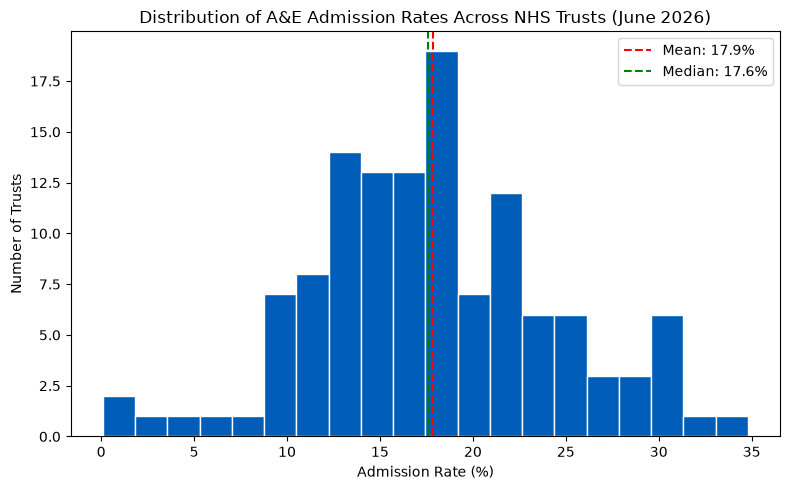

In [34]:
plt.figure(figsize=(8,5))
plt.hist(ae_jun2026_admitting['admission_rate_pct'], bins=20, color='#005EB8', edgecolor='white')
plt.axvline(ae_jun2026_admitting['admission_rate_pct'].mean(), color='red', linestyle='--', label=f"Mean: {ae_jun2026_admitting['admission_rate_pct'].mean():.1f}%")
plt.axvline(ae_jun2026_admitting['admission_rate_pct'].median(), color='green', linestyle='--', label=f"Median: {ae_jun2026_admitting['admission_rate_pct'].median():.1f}%")
plt.title('Distribution of A&E Admission Rates Across NHS Trusts (June 2026)')
plt.xlabel('Admission Rate (%)')
plt.ylabel('Number of Trusts')
plt.legend()
plt.tight_layout()
plt.savefig('admission_rate_distribution.png', dpi=200)
plt.show()

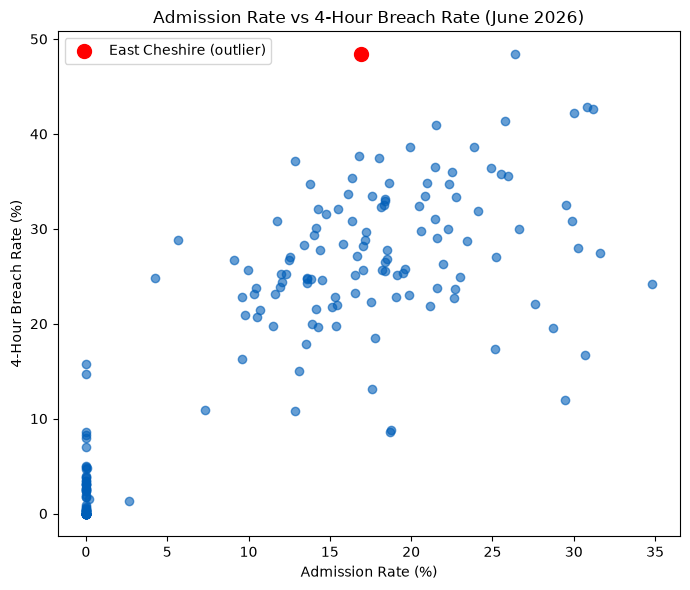

In [35]:
plt.figure(figsize=(7,6))
plt.scatter(ae_jun2026_clean_df['admission_rate_pct'], ae_jun2026_clean_df['breach_rate_pct_4hr'], color='#005EB8', alpha=0.6)
plt.title('Admission Rate vs 4-Hour Breach Rate (June 2026)')
plt.xlabel('Admission Rate (%)')
plt.ylabel('4-Hour Breach Rate (%)')

# Highlight East Cheshire specifically
ec = ae_jun2026_clean_df[ae_jun2026_clean_df['Org name'] == 'EAST CHESHIRE NHS TRUST']
plt.scatter(ec['admission_rate_pct'], ec['breach_rate_pct_4hr'], color='red', s=100, label='East Cheshire (outlier)')
plt.legend()
plt.tight_layout()
plt.savefig('admission_vs_breach_scatter.png', dpi=200)
plt.show()

## 9. June 2026 — Severity Ratio (Cascading Delay Analysis)

Calculating the ratio of severe (12+ hr) to moderate (4-12 hr) DTA waits, to identify 
Trusts where delays disproportionately escalate to the most extreme category.

**Finding:** Nottingham University Hospitals showed the most extreme severity 
imbalance (ratio: 6.93) — 1,067 patients waited 12+ hours after the decision to 
admit, compared to only 155 in the 4-12 hour range. Verified against raw patient 
counts to confirm this reflects genuine volume, not a small-sample artifact.

In [36]:
ae_jun2026_clean_df['severity_ratio'] = (ae_jun2026_clean_df['breach_rate_pct_12plus_hrs'] / 
                                         ae_jun2026_clean_df['breach_rate_pct_4to12_hrs']
)

In [37]:
ae_jun2026_clean_df[['Org name','admission_rate_pct','breach_rate_pct_4hr','breach_rate_pct_4to12_hrs','breach_rate_pct_12plus_hrs','severity_ratio']].sort_values(
    'severity_ratio',ascending=False).head(10)

,Org name,admission_rate_pct,breach_rate_pct_4hr,breach_rate_pct_4to12_hrs,breach_rate_pct_12plus_hrs,severity_ratio
116,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,18.40,33.14,0.61,4.23,6.934426
61,MEDWAY NHS FOUNDATION TRUST,9.95,25.71,1.58,4.78,3.025316
67,KINGSTON AND RICHMOND NHS FOUNDATION TRUST,18.41,26.54,1.40,3.55,2.535714
137,CROYDON HEALTH SERVICES NHS TRUST,5.66,28.77,1.37,3.28,2.394161
176,NORTHAMPTON GENERAL HOSPITAL NHS TRUST,17.17,28.79,2.73,6.44,2.358974
36,MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST,22.54,35.97,2.96,6.77,2.287162
39,EAST LANCASHIRE HOSPITALS NHS TRUST,15.46,22.00,1.26,2.86,2.269841
91,ROYAL FREE LONDON NHS FOUNDATION TRUST,14.26,19.66,2.01,3.95,1.965174
188,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,19.91,38.60,3.31,6.24,1.885196
160,NORTH CHESHIRE AND MERSEY NHS FOUNDATION TRUST,13.57,24.69,3.51,6.56,1.868946


In [38]:
ae_jun2026_clean_df[ae_jun2026_clean_df['Org name'] == 'NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST'].T

,116
Period,MSitAE-JUNE-2026
Org Code,RX1
Parent Org,NHS ENGLAND MIDLANDS
Org name,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST
A&E attendances Type 1,12935
A&E attendances Type 2,2218
A&E attendances Other A&E Department,9740
A&E attendances Booked Appointments Type 1,0
A&E attendances Booked Appointments Type 2,0
A&E attendances Booked Appointments Other Department,350


## 10. June 2026 — Regional Comparison

Grouping Trusts by NHS region (Parent Org) to compare average performance.

**Finding:** NHS England North West had both the highest average 4-hour breach rate 
(23.6%) and tied for the highest severe (12+ hr) wait rate (2.79%) among all regions, 
while North East and Yorkshire had a relatively high overall breach rate (20.1%) but 
the lowest severe-wait rate (0.68%).

In [39]:
ae_jun2026_clean_df.groupby('Parent Org')[['total_attendances','admission_rate_pct','breach_rate_pct_4hr','breach_rate_pct_4to12_hrs','breach_rate_pct_12plus_hrs']].mean().round(2)

,total_attendances,admission_rate_pct,breach_rate_pct_4hr,breach_rate_pct_4to12_hrs,breach_rate_pct_12plus_hrs
Parent Org,,,,,
NHS ENGLAND EAST OF ENGLAND,15228.56,15.08,22.14,3.25,1.62
NHS ENGLAND LONDON,17852.62,9.85,18.66,1.90,1.51
NHS ENGLAND MIDLANDS,11747.68,10.64,16.45,2.11,1.65
NHS ENGLAND NORTH EAST AND YORKSHIRE,12864.83,14.55,20.08,2.87,0.68
NHS ENGLAND NORTH WEST,12688.04,14.30,23.60,2.79,2.79
NHS ENGLAND SOUTH EAST,10897.09,10.68,15.15,1.63,1.16
NHS ENGLAND SOUTH WEST,9580.48,12.17,21.49,2.85,1.42


In [40]:
ae_jun2026_clean_df.groupby('Parent Org')[['total_attendances','admission_rate_pct','breach_rate_pct_4hr','breach_rate_pct_4to12_hrs','breach_rate_pct_12plus_hrs']].mean().round(2).sort_values('breach_rate_pct_4hr', ascending=False)

,total_attendances,admission_rate_pct,breach_rate_pct_4hr,breach_rate_pct_4to12_hrs,breach_rate_pct_12plus_hrs
Parent Org,,,,,
NHS ENGLAND NORTH WEST,12688.04,14.30,23.60,2.79,2.79
NHS ENGLAND EAST OF ENGLAND,15228.56,15.08,22.14,3.25,1.62
NHS ENGLAND SOUTH WEST,9580.48,12.17,21.49,2.85,1.42
NHS ENGLAND NORTH EAST AND YORKSHIRE,12864.83,14.55,20.08,2.87,0.68
NHS ENGLAND LONDON,17852.62,9.85,18.66,1.90,1.51
NHS ENGLAND MIDLANDS,11747.68,10.64,16.45,2.11,1.65
NHS ENGLAND SOUTH EAST,10897.09,10.68,15.15,1.63,1.16


## 11. May 2026 — Load, Clean, and Derive Metrics

Repeating the same pipeline as June: load data, remove the Total row, calculate 
total attendances, admission rate, breach rate, and DTA wait sub-categories.

In [41]:
ae_may2026_df = pd.read_csv('May-2026-CSV-F4flrg.csv')

In [42]:
ae_may2026_df.head()

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Attendances over 4hrs Other Department,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions
0,MSitAE-MAY-2026,AJN,NHS ENGLAND NORTH EAST AND YORKSHIRE,WORKINGTON HEALTH LIMITED,0,0,429,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,MSitAE-MAY-2026,AQN04,NHS ENGLAND SOUTH EAST,PHL LYMINGTON UTC,0,0,3565,0,0,2,...,82,0,0,0,0,0,0,0,0,0
2,MSitAE-MAY-2026,NTV0B,NHS ENGLAND SOUTH EAST,ASHFORD WALK-IN-CENTRE,0,0,2552,0,0,0,...,67,0,0,0,0,0,0,0,0,0
3,MSitAE-MAY-2026,NTV0W,NHS ENGLAND SOUTH EAST,WOKING WALK IN CENTRE,0,0,2834,0,0,0,...,170,0,0,0,0,0,0,0,0,0
4,MSitAE-MAY-2026,RBQ,NHS ENGLAND NORTH WEST,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,137


In [43]:
ae_may2026_df.shape

(193, 22)

In [44]:
ae_may2026_df.isna().sum()

Period                                                        0
Org Code                                                      0
Parent Org                                                    0
Org name                                                      0
A&E attendances Type 1                                        0
A&E attendances Type 2                                        0
A&E attendances Other A&E Department                          0
A&E attendances Booked Appointments Type 1                    0
A&E attendances Booked Appointments Type 2                    0
A&E attendances Booked Appointments Other Department          0
Attendances over 4hrs Type 1                                  0
Attendances over 4hrs Type 2                                  0
Attendances over 4hrs Other Department                        0
Attendances over 4hrs Booked Appointments Type 1              0
Attendances over 4hrs Booked Appointments Type 2              0
Attendances over 4hrs Booked Appointment

In [45]:
ae_may2026_df.columns

Index(['Period', 'Org Code', 'Parent Org', 'Org name',
       'A&E attendances Type 1', 'A&E attendances Type 2',
       'A&E attendances Other A&E Department',
       'A&E attendances Booked Appointments Type 1',
       'A&E attendances Booked Appointments Type 2',
       'A&E attendances Booked Appointments Other Department',
       'Attendances over 4hrs Type 1', 'Attendances over 4hrs Type 2',
       'Attendances over 4hrs Other Department',
       'Attendances over 4hrs Booked Appointments Type 1',
       'Attendances over 4hrs Booked Appointments Type 2',
       'Attendances over 4hrs Booked Appointments Other Department',
       'Patients who have waited 4-12 hs from DTA to admission',
       'Patients who have waited 12+ hrs from DTA to admission',
       'Emergency admissions via A&E - Type 1',
       'Emergency admissions via A&E - Type 2',
       'Emergency admissions via A&E - Other A&E department',
       'Other emergency admissions'],
      dtype='object')

In [46]:
ae_may2026_df['total_unplanned_attendances'] = (ae_may2026_df['A&E attendances Type 1'] +
                                                       ae_may2026_df['A&E attendances Type 2'] +
                                                       ae_may2026_df['A&E attendances Other A&E Department'])

In [47]:
ae_may2026_df['total_booked_attendances'] = (ae_may2026_df['A&E attendances Booked Appointments Type 1'] +
                                                    ae_may2026_df['A&E attendances Booked Appointments Type 2'] +
                                                    ae_may2026_df['A&E attendances Booked Appointments Other Department'])

In [48]:
ae_may2026_df['total_attendances'] = (ae_may2026_df['A&E attendances Type 1'] +
                                            ae_may2026_df['A&E attendances Type 2'] +
                                            ae_may2026_df['A&E attendances Other A&E Department'] +
                                            ae_may2026_df['A&E attendances Booked Appointments Type 1'] +
                                            ae_may2026_df['A&E attendances Booked Appointments Type 2'] +
                                            ae_may2026_df['A&E attendances Booked Appointments Other Department'])


In [49]:
ae_may2026_df.shape

(193, 25)

In [50]:
ae_may2026_df.head()

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions,total_unplanned_attendances,total_booked_attendances,total_attendances
0,MSitAE-MAY-2026,AJN,NHS ENGLAND NORTH EAST AND YORKSHIRE,WORKINGTON HEALTH LIMITED,0,0,429,0,0,0,...,0,0,0,0,0,0,0,429,0,429
1,MSitAE-MAY-2026,AQN04,NHS ENGLAND SOUTH EAST,PHL LYMINGTON UTC,0,0,3565,0,0,2,...,0,0,0,0,0,0,0,3565,2,3567
2,MSitAE-MAY-2026,NTV0B,NHS ENGLAND SOUTH EAST,ASHFORD WALK-IN-CENTRE,0,0,2552,0,0,0,...,0,0,0,0,0,0,0,2552,0,2552
3,MSitAE-MAY-2026,NTV0W,NHS ENGLAND SOUTH EAST,WOKING WALK IN CENTRE,0,0,2834,0,0,0,...,0,0,0,0,0,0,0,2834,0,2834
4,MSitAE-MAY-2026,RBQ,NHS ENGLAND NORTH WEST,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,0,0,0,0,0,0,...,0,0,0,0,0,0,137,0,0,0


In [51]:
ae_may2026_df.sort_values('total_attendances',ascending=False).head()

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions,total_unplanned_attendances,total_booked_attendances,total_attendances
192,TOTAL,TOTAL,TOTAL,TOTAL,1466119,52381,860272,27226,439,50961,...,558,78378,50212,395328,1417,5088,131447,2378772,78626,2457398
174,MSitAE-MAY-2026,RRK,NHS ENGLAND MIDLANDS,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,36269,429,13723,0,0,216,...,2,1638,2620,10492,0,0,7421,50421,216,50637
113,MSitAE-MAY-2026,R0A,NHS ENGLAND NORTH WEST,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,27846,3450,11594,3154,415,829,...,24,3158,91,5880,129,73,465,42890,4398,47288
152,MSitAE-MAY-2026,R1H,NHS ENGLAND LONDON,BARTS HEALTH NHS TRUST,26667,880,19721,0,0,0,...,0,994,1157,4328,0,48,1199,47268,0,47268
186,MSitAE-MAY-2026,RAL,NHS ENGLAND LONDON,ROYAL FREE LONDON NHS FOUNDATION TRUST,26608,458,17712,187,3,227,...,19,926,1862,6471,0,121,797,44778,417,45195


In [52]:
ae_may2026_df[['Org name','total_unplanned_attendances','total_booked_attendances','total_attendances']].sort_values('total_attendances',ascending=False)

,Org name,total_unplanned_attendances,total_booked_attendances,total_attendances
192,TOTAL,2378772,78626,2457398
174,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,50421,216,50637
113,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,42890,4398,47288
152,BARTS HEALTH NHS TRUST,47268,0,47268
186,ROYAL FREE LONDON NHS FOUNDATION TRUST,44778,417,45195
...,...,...,...,...
4,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,0,0,0
15,THE CHRISTIE NHS FOUNDATION TRUST,0,0,0
128,THE ROBERT JONES AND AGNES HUNT ORTHOPAEDIC HO...,0,0,0
109,COVENTRY AND WARWICKSHIRE PARTNERSHIP NHS TRUST,0,0,0


In [53]:
ae_may2026_df['Org name'] == 'TOTAL'

0      False
1      False
2      False
3      False
4      False
       ...  
188    False
189    False
190    False
191    False
192    False
Name: Org name, Length: 193, dtype: bool

In [54]:
# Print the exact value with quotes visible, to spot hidden spaces
print(repr(ae_may2026_df.loc[192, 'Org name']))

'TOTAL '


In [55]:
ae_may2026_df['Org name'].unique()

array(['WORKINGTON HEALTH LIMITED', 'PHL LYMINGTON UTC',
       'ASHFORD WALK-IN-CENTRE', 'WOKING WALK IN CENTRE',
       'LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDATION TRUST',
       'CORNWALL PARTNERSHIP NHS FOUNDATION TRUST',
       'HAMPSHIRE AND ISLE OF WIGHT HEALTHCARE NHS FOUNDATION TRUST',
       'KENT COMMUNITY HEALTH NHS FOUNDATION TRUST',
       'MIRIAM MINOR EMERGENCY', 'WHITSTABLE MEDICAL PRACTICE',
       'LATHAM HOUSE MEDICAL PRACTICE', 'HERTS URGENT CARE (ASCOTS LANE)',
       'FIRST COMMUNITY HEALTH AND CARE CIC',
       'SKELMERSDALE WALK IN CENTRE', 'PAULTON MEMORIAL HOSPITAL',
       'THE CHRISTIE NHS FOUNDATION TRUST',
       'CALDERDALE AND HUDDERSFIELD NHS FOUNDATION TRUST',
       'MARKET HARBOROUGH MED.CTR', 'BARKING HOSPITAL UTC',
       'HAROLD WOOD POLYCLINIC UTC',
       'DORSET HEALTHCARE UNIVERSITY NHS FOUNDATION TRUST',
       'WORCESTERSHIRE ACUTE HOSPITALS NHS TRUST',
       'OKEHAMPTON MEDICAL CENTRE',
       "ALDER HEY CHILDREN'S NHS FOUNDATION T

In [56]:
ae_may2026_df[ae_may2026_df['Org name'].str.strip() == 'TOTAL']

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions,total_unplanned_attendances,total_booked_attendances,total_attendances
192,TOTAL,TOTAL,TOTAL,TOTAL,1466119,52381,860272,27226,439,50961,...,558,78378,50212,395328,1417,5088,131447,2378772,78626,2457398


In [57]:
ae_may2026_clean_df = ae_may2026_df[ae_may2026_df['Org name'].str.strip() != 'TOTAL'].copy()

In [58]:
ae_may2026_clean_df.shape

(192, 25)

In [59]:
ae_may2026_clean_df['total_emergency_admissions'] = (ae_may2026_clean_df['Emergency admissions via A&E - Type 1'] +
                                              ae_may2026_clean_df['Emergency admissions via A&E - Type 2'] +
                                              ae_may2026_clean_df['Emergency admissions via A&E - Other A&E department'])

In [60]:
ae_may2026_clean_df['admission_rate_pct'] = ((ae_may2026_clean_df['total_emergency_admissions'] /
                                                    ae_may2026_clean_df['total_attendances'])*100).round(2)

In [61]:
ae_may2026_clean_df.head()

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions,total_unplanned_attendances,total_booked_attendances,total_attendances,total_emergency_admissions,admission_rate_pct
0,MSitAE-MAY-2026,AJN,NHS ENGLAND NORTH EAST AND YORKSHIRE,WORKINGTON HEALTH LIMITED,0,0,429,0,0,0,...,0,0,0,0,0,429,0,429,0,0.0
1,MSitAE-MAY-2026,AQN04,NHS ENGLAND SOUTH EAST,PHL LYMINGTON UTC,0,0,3565,0,0,2,...,0,0,0,0,0,3565,2,3567,0,0.0
2,MSitAE-MAY-2026,NTV0B,NHS ENGLAND SOUTH EAST,ASHFORD WALK-IN-CENTRE,0,0,2552,0,0,0,...,0,0,0,0,0,2552,0,2552,0,0.0
3,MSitAE-MAY-2026,NTV0W,NHS ENGLAND SOUTH EAST,WOKING WALK IN CENTRE,0,0,2834,0,0,0,...,0,0,0,0,0,2834,0,2834,0,0.0
4,MSitAE-MAY-2026,RBQ,NHS ENGLAND NORTH WEST,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,0,0,0,0,0,0,...,0,0,0,0,137,0,0,0,0,NaN


In [62]:
ae_may2026_clean_df.isna().sum()

Period                                                        0
Org Code                                                      0
Parent Org                                                    0
Org name                                                      0
A&E attendances Type 1                                        0
A&E attendances Type 2                                        0
A&E attendances Other A&E Department                          0
A&E attendances Booked Appointments Type 1                    0
A&E attendances Booked Appointments Type 2                    0
A&E attendances Booked Appointments Other Department          0
Attendances over 4hrs Type 1                                  0
Attendances over 4hrs Type 2                                  0
Attendances over 4hrs Other Department                        0
Attendances over 4hrs Booked Appointments Type 1              0
Attendances over 4hrs Booked Appointments Type 2              0
Attendances over 4hrs Booked Appointment

In [63]:
ae_may2026_clean_df[ae_may2026_clean_df['admission_rate_pct'].isna()]

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions,total_unplanned_attendances,total_booked_attendances,total_attendances,total_emergency_admissions,admission_rate_pct
4,MSitAE-MAY-2026,RBQ,NHS ENGLAND NORTH WEST,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,0,0,0,0,0,0,...,0,0,0,0,137,0,0,0,0,NaN
15,MSitAE-MAY-2026,RBV,NHS ENGLAND NORTH WEST,THE CHRISTIE NHS FOUNDATION TRUST,0,0,0,0,0,0,...,0,0,0,0,840,0,0,0,0,NaN
32,MSitAE-MAY-2026,RAN,NHS ENGLAND LONDON,ROYAL NATIONAL ORTHOPAEDIC HOSPITAL NHS TRUST,0,0,0,0,0,0,...,0,0,0,0,8,0,0,0,0,NaN
54,MSitAE-MAY-2026,RXG,NHS ENGLAND NORTH EAST AND YORKSHIRE,SOUTH WEST YORKSHIRE PARTNERSHIP NHS FOUNDATIO...,0,0,0,0,0,0,...,0,0,0,0,132,0,0,0,0,NaN
121,MSitAE-MAY-2026,RET,NHS ENGLAND NORTH WEST,THE WALTON CENTRE NHS FOUNDATION TRUST,0,0,0,0,0,0,...,0,0,0,0,176,0,0,0,0,NaN
128,MSitAE-MAY-2026,RL1,NHS ENGLAND MIDLANDS,THE ROBERT JONES AND AGNES HUNT ORTHOPAEDIC HO...,0,0,0,0,0,0,...,0,0,0,0,39,0,0,0,0,NaN


In [64]:
ae_may2026_clean_df[['Org name','total_attendances','total_emergency_admissions','admission_rate_pct']].sort_values('admission_rate_pct',ascending=False)

,Org name,total_attendances,total_emergency_admissions,admission_rate_pct
5,CORNWALL PARTNERSHIP NHS FOUNDATION TRUST,0,13,inf
20,DORSET HEALTHCARE UNIVERSITY NHS FOUNDATION TRUST,0,3,inf
109,COVENTRY AND WARWICKSHIRE PARTNERSHIP NHS TRUST,0,7,inf
123,BARNSLEY HOSPITAL NHS FOUNDATION TRUST,9749,3344,34.30
141,NORTH BRISTOL NHS TRUST,9890,3134,31.69
...,...,...,...,...
15,THE CHRISTIE NHS FOUNDATION TRUST,0,0,NaN
32,ROYAL NATIONAL ORTHOPAEDIC HOSPITAL NHS TRUST,0,0,NaN
54,SOUTH WEST YORKSHIRE PARTNERSHIP NHS FOUNDATIO...,0,0,NaN
121,THE WALTON CENTRE NHS FOUNDATION TRUST,0,0,NaN


In [65]:
ae_may2026_clean_df['admission_rate_pct']= ae_may2026_clean_df['admission_rate_pct'].replace(to_replace=(np.inf,-np.inf),value=np.nan)

In [66]:
ae_may2026_clean_df.isna().sum()

Period                                                        0
Org Code                                                      0
Parent Org                                                    0
Org name                                                      0
A&E attendances Type 1                                        0
A&E attendances Type 2                                        0
A&E attendances Other A&E Department                          0
A&E attendances Booked Appointments Type 1                    0
A&E attendances Booked Appointments Type 2                    0
A&E attendances Booked Appointments Other Department          0
Attendances over 4hrs Type 1                                  0
Attendances over 4hrs Type 2                                  0
Attendances over 4hrs Other Department                        0
Attendances over 4hrs Booked Appointments Type 1              0
Attendances over 4hrs Booked Appointments Type 2              0
Attendances over 4hrs Booked Appointment

In [67]:
ae_may2026_clean_df[['Org name','total_attendances','total_emergency_admissions','admission_rate_pct']].sort_values('admission_rate_pct',ascending=False)

,Org name,total_attendances,total_emergency_admissions,admission_rate_pct
123,BARNSLEY HOSPITAL NHS FOUNDATION TRUST,9749,3344,34.30
141,NORTH BRISTOL NHS TRUST,9890,3134,31.69
45,MERSEY AND WEST LANCASHIRE TEACHING HOSPITALS ...,25748,8065,31.32
49,NORTHERN LINCOLNSHIRE AND GOOLE NHS FOUNDATION...,17924,5487,30.61
154,ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST,9451,2872,30.39
...,...,...,...,...
32,ROYAL NATIONAL ORTHOPAEDIC HOSPITAL NHS TRUST,0,0,NaN
54,SOUTH WEST YORKSHIRE PARTNERSHIP NHS FOUNDATIO...,0,0,NaN
109,COVENTRY AND WARWICKSHIRE PARTNERSHIP NHS TRUST,0,7,NaN
121,THE WALTON CENTRE NHS FOUNDATION TRUST,0,0,NaN


## 12. May 2026 — Statistical Analysis and Severity Ratio

**Finding:** Nottingham University Hospitals again showed the most extreme severity 
ratio in May (7.28) — 1,142 patients waited 12+ hours, compared to only 158 in the 
4-12 hour range. This closely matches June's figures (1,067 vs 155), confirming the 
pattern is persistent and structural, not a single-month anomaly.

In [68]:
ae_may2026_clean_df['admission_rate_pct'].describe()

count    183.000000
mean      12.275792
std        9.940762
min        0.000000
25%        0.000000
50%       14.080000
75%       19.510000
max       34.300000
Name: admission_rate_pct, dtype: float64

In [69]:
ae_may2026_admitting = ae_may2026_clean_df[
    (ae_may2026_clean_df['admission_rate_pct'] > 0) & 
    (ae_may2026_clean_df['admission_rate_pct'].notna())
]

In [70]:
ae_may2026_admitting[['Org name','total_attendances','total_emergency_admissions','admission_rate_pct']].sort_values('admission_rate_pct',ascending=False)

,Org name,total_attendances,total_emergency_admissions,admission_rate_pct
123,BARNSLEY HOSPITAL NHS FOUNDATION TRUST,9749,3344,34.30
141,NORTH BRISTOL NHS TRUST,9890,3134,31.69
45,MERSEY AND WEST LANCASHIRE TEACHING HOSPITALS ...,25748,8065,31.32
49,NORTHERN LINCOLNSHIRE AND GOOLE NHS FOUNDATION...,17924,5487,30.61
154,ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST,9451,2872,30.39
...,...,...,...,...
50,UNIVERSITY HOSPITALS COVENTRY AND WARWICKSHIRE...,22326,903,4.04
165,BERKSHIRE HEALTHCARE NHS FOUNDATION TRUST,1509,37,2.45
52,QUEEN VICTORIA HOSPITAL NHS FOUNDATION TRUST,1440,10,0.69
70,MOORFIELDS EYE HOSPITAL NHS FOUNDATION TRUST,6494,1,0.02


In [71]:
ae_may2026_admitting['admission_rate_pct'].describe()

count    126.000000
mean      17.829127
std        6.639044
min        0.010000
25%       13.840000
50%       17.865000
75%       21.962500
max       34.300000
Name: admission_rate_pct, dtype: float64

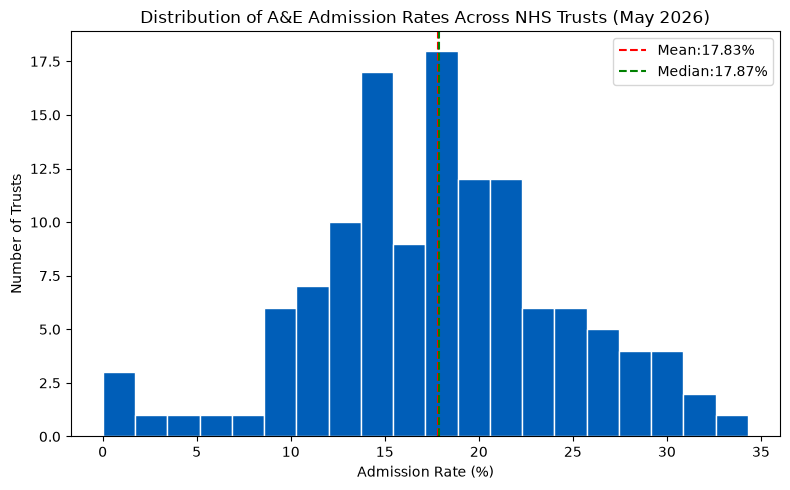

In [72]:
plt.figure(figsize=(8,5))
plt.hist(ae_may2026_admitting['admission_rate_pct'],bins=20,color='#005EB8',edgecolor='white')
plt.axvline(ae_may2026_admitting['admission_rate_pct'].mean(),color='red',linestyle='--',
            label=f"Mean:{ae_may2026_admitting['admission_rate_pct'].mean():.2f}%")
plt.axvline(ae_may2026_admitting['admission_rate_pct'].median(),color='green',linestyle='--',
            label=f"Median:{ae_may2026_admitting['admission_rate_pct'].median():.2f}%")
plt.title('Distribution of A&E Admission Rates Across NHS Trusts (May 2026)')
plt.xlabel('Admission Rate (%)')
plt.ylabel('Number of Trusts')

plt.tight_layout()
plt.legend()
plt.savefig('admission_rate_distribution_may_2026.png', dpi=200)
plt.show()

In [73]:
ae_may2026_clean_df.columns

Index(['Period', 'Org Code', 'Parent Org', 'Org name',
       'A&E attendances Type 1', 'A&E attendances Type 2',
       'A&E attendances Other A&E Department',
       'A&E attendances Booked Appointments Type 1',
       'A&E attendances Booked Appointments Type 2',
       'A&E attendances Booked Appointments Other Department',
       'Attendances over 4hrs Type 1', 'Attendances over 4hrs Type 2',
       'Attendances over 4hrs Other Department',
       'Attendances over 4hrs Booked Appointments Type 1',
       'Attendances over 4hrs Booked Appointments Type 2',
       'Attendances over 4hrs Booked Appointments Other Department',
       'Patients who have waited 4-12 hs from DTA to admission',
       'Patients who have waited 12+ hrs from DTA to admission',
       'Emergency admissions via A&E - Type 1',
       'Emergency admissions via A&E - Type 2',
       'Emergency admissions via A&E - Other A&E department',
       'Other emergency admissions', 'total_unplanned_attendances',
       

In [74]:
ae_may2026_clean_df['total_over_4hrs'] = ( ae_may2026_clean_df['Attendances over 4hrs Type 1'] +
                            ae_may2026_clean_df['Attendances over 4hrs Type 2'] +
                            ae_may2026_clean_df['Attendances over 4hrs Other Department'] +
                            ae_may2026_clean_df['Attendances over 4hrs Booked Appointments Type 1'] +
                            ae_may2026_clean_df['Attendances over 4hrs Booked Appointments Type 2'] +
                            ae_may2026_clean_df['Attendances over 4hrs Booked Appointments Other Department'])

In [75]:
ae_may2026_clean_df['breach_rate_pct_4hr'] = ((ae_may2026_clean_df['total_over_4hrs'] /
                                                       ae_may2026_clean_df['total_attendances'])*100).round(2)

In [76]:
ae_may2026_clean_df['breach_rate_pct_4to12_hrs'] = ((ae_may2026_clean_df['Patients who have waited 4-12 hs from DTA to admission'] /
                                                       ae_may2026_clean_df['total_attendances'])*100).round(2)

In [77]:
ae_may2026_clean_df['breach_rate_pct_12plus_hrs'] = ((ae_may2026_clean_df['Patients who have waited 12+ hrs from DTA to admission'] /
                                                       ae_may2026_clean_df['total_attendances'])*100).round(2)

In [78]:
ae_may2026_clean_df[['Org name','total_attendances','total_over_4hrs','total_emergency_admissions','admission_rate_pct',
                     'breach_rate_pct_4hr','breach_rate_pct_4to12_hrs','breach_rate_pct_12plus_hrs']].sort_values('breach_rate_pct_4hr',ascending=False).head(10)

,Org name,total_attendances,total_over_4hrs,total_emergency_admissions,admission_rate_pct,breach_rate_pct_4hr,breach_rate_pct_4to12_hrs,breach_rate_pct_12plus_hrs
97,EAST CHESHIRE NHS TRUST,4877,2471,865,17.74,50.67,5.47,6.73
150,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,14076,6618,3777,26.83,47.02,5.85,6.74
154,ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST,9451,4106,2872,30.39,43.45,10.32,1.62
72,SURREY AND SUSSEX HEALTHCARE NHS TRUST,10252,4245,2954,28.81,41.41,4.53,6.41
120,AIREDALE NHS FOUNDATION TRUST,6948,2861,1438,20.70,41.18,5.57,4.13
76,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,14421,5671,3765,26.11,39.32,6.64,3.18
71,ASHFORD AND ST PETER'S HOSPITALS NHS FOUNDATIO...,10795,4230,2518,23.33,39.18,4.99,4.00
163,EPSOM AND ST HELIER UNIVERSITY HOSPITALS NHS T...,13745,5347,2052,14.93,38.90,3.97,5.95
178,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,11204,4330,2181,19.47,38.65,3.90,7.66
130,HAMPSHIRE HOSPITALS NHS FOUNDATION TRUST,15036,5702,3643,24.23,37.92,2.22,0.22


In [79]:
ae_may2026_clean_df

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Other emergency admissions,total_unplanned_attendances,total_booked_attendances,total_attendances,total_emergency_admissions,admission_rate_pct,total_over_4hrs,breach_rate_pct_4hr,breach_rate_pct_4to12_hrs,breach_rate_pct_12plus_hrs
0,MSitAE-MAY-2026,AJN,NHS ENGLAND NORTH EAST AND YORKSHIRE,WORKINGTON HEALTH LIMITED,0,0,429,0,0,0,...,0,429,0,429,0,0.00,0,0.00,0.00,0.00
1,MSitAE-MAY-2026,AQN04,NHS ENGLAND SOUTH EAST,PHL LYMINGTON UTC,0,0,3565,0,0,2,...,0,3565,2,3567,0,0.00,82,2.30,0.00,0.00
2,MSitAE-MAY-2026,NTV0B,NHS ENGLAND SOUTH EAST,ASHFORD WALK-IN-CENTRE,0,0,2552,0,0,0,...,0,2552,0,2552,0,0.00,67,2.63,0.00,0.00
3,MSitAE-MAY-2026,NTV0W,NHS ENGLAND SOUTH EAST,WOKING WALK IN CENTRE,0,0,2834,0,0,0,...,0,2834,0,2834,0,0.00,170,6.00,0.00,0.00
4,MSitAE-MAY-2026,RBQ,NHS ENGLAND NORTH WEST,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,0,0,0,0,0,0,...,137,0,0,0,0,NaN,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,MSitAE-MAY-2026,RBD,NHS ENGLAND SOUTH WEST,DORSET COUNTY HOSPITAL NHS FOUNDATION TRUST,4999,0,0,490,0,4714,...,506,4999,5204,10203,1952,19.13,2612,25.60,2.66,0.83
188,MSitAE-MAY-2026,RXK,NHS ENGLAND MIDLANDS,SANDWELL AND WEST BIRMINGHAM HOSPITALS NHS TRUST,11768,1086,8725,371,0,0,...,78,21579,371,21950,2764,12.59,5193,23.66,3.76,1.23
189,MSitAE-MAY-2026,RDU,NHS ENGLAND SOUTH EAST,FRIMLEY HEALTH NHS FOUNDATION TRUST,24282,866,11819,0,0,0,...,167,36967,0,36967,6597,17.85,9199,24.88,3.11,2.05
190,MSitAE-MAY-2026,RXC,NHS ENGLAND SOUTH EAST,EAST SUSSEX HEALTHCARE NHS TRUST,9759,0,2517,1948,0,1714,...,482,12276,3662,15938,2558,16.05,4312,27.05,1.81,1.15


In [80]:
ae_may2026_clean_df[['breach_rate_pct_4to12_hrs','breach_rate_pct_12plus_hrs']].corr()

,breach_rate_pct_4to12_hrs,breach_rate_pct_12plus_hrs
breach_rate_pct_4to12_hrs,1.000000,0.493021
breach_rate_pct_12plus_hrs,0.493021,1.000000


In [81]:
ae_may2026_clean_df['severity_ratio'] = (ae_may2026_clean_df['breach_rate_pct_12plus_hrs'] / 
                                         ae_may2026_clean_df['breach_rate_pct_4to12_hrs']
)

In [82]:
ae_may2026_clean_df[['Org name','total_attendances','total_emergency_admissions','admission_rate_pct',
                     'breach_rate_pct_4hr','breach_rate_pct_4to12_hrs','breach_rate_pct_12plus_hrs','severity_ratio']].sort_values('severity_ratio',ascending=False).head(10)

,Org name,total_attendances,total_emergency_admissions,admission_rate_pct,breach_rate_pct_4hr,breach_rate_pct_4to12_hrs,breach_rate_pct_12plus_hrs,severity_ratio
148,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,25692,4705,18.31,33.68,0.61,4.44,7.278689
106,EAST LANCASHIRE HOSPITALS NHS TRUST,26385,4213,15.97,20.11,1.08,4.21,3.898148
126,CROYDON HEALTH SERVICES NHS TRUST,18656,1057,5.67,27.42,1.22,3.62,2.967213
134,MEDWAY NHS FOUNDATION TRUST,17148,1716,10.01,22.95,1.69,4.93,2.917160
184,GLOUCESTERSHIRE HOSPITALS NHS FOUNDATION TRUST,14498,2580,17.80,36.15,1.83,3.72,2.032787
186,ROYAL FREE LONDON NHS FOUNDATION TRUST,45195,6592,14.59,19.69,2.05,4.12,2.009756
178,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,11204,2181,19.47,38.65,3.90,7.66,1.964103
179,PORTSMOUTH HOSPITALS UNIVERSITY NHS TRUST,18672,3185,17.06,25.99,3.48,6.49,1.864943
100,NORTHAMPTON GENERAL HOSPITAL NHS TRUST,14006,2341,16.71,26.61,3.21,5.95,1.853583
69,KETTERING GENERAL HOSPITAL NHS FOUNDATION TRUST,19904,1894,9.52,19.66,2.17,3.88,1.788018


In [83]:
ae_may2026_clean_df[ae_may2026_clean_df['Org name'] == 'NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST'].T

,148
Period,MSitAE-MAY-2026
Org Code,RX1
Parent Org,NHS ENGLAND MIDLANDS
Org name,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST
A&E attendances Type 1,13270
A&E attendances Type 2,1955
A&E attendances Other A&E Department,10124
A&E attendances Booked Appointments Type 1,0
A&E attendances Booked Appointments Type 2,0
A&E attendances Booked Appointments Other Department,343


## 13. May vs June — Merged Comparison

Merging both months on Org Code to calculate month-over-month change per Trust.

**Finding:** Several Trusts — notably Salisbury, North Bristol, and County Durham and 
Darlington — showed sharp breach rate increases (+3.9 to +6.7 percentage points) 
between May and June despite flat or improving admission rates, indicating their 
decline is not explained by rising case complexity and likely reflects a separate 
operational factor worth further investigation.

In [84]:
merged_df = pd.merge(ae_jun2026_clean_df,ae_may2026_clean_df,on='Org Code',suffixes=('_jun','_may'))

In [85]:
merged_df.shape

(192, 61)

In [86]:
ae_jun2026_clean_df.shape,ae_may2026_clean_df.shape

((192, 30), (192, 32))

In [87]:
ae_jun2026_clean_df.columns

Index(['Period', 'Org Code', 'Parent Org', 'Org name',
       'A&E attendances Type 1', 'A&E attendances Type 2',
       'A&E attendances Other A&E Department',
       'A&E attendances Booked Appointments Type 1',
       'A&E attendances Booked Appointments Type 2',
       'A&E attendances Booked Appointments Other Department',
       'Attendances over 4hrs Type 1', 'Attendances over 4hrs Type 2',
       'Attendances over 4hrs Other Department',
       'Attendances over 4hrs Booked Appointments Type 1',
       'Attendances over 4hrs Booked Appointments Type 2',
       'Attendances over 4hrs Booked Appointments Other Department',
       'Patients who have waited 4-12 hs from DTA to admission',
       'Patients who have waited 12+ hrs from DTA to admission',
       'Emergency admissions via A&E - Type 1',
       'Emergency admissions via A&E - Type 2',
       'Emergency admissions via A&E - Other A&E department',
       'Other emergency admissions', 'total_attendances',
       'total_eme

In [88]:
ae_may2026_clean_df.columns

Index(['Period', 'Org Code', 'Parent Org', 'Org name',
       'A&E attendances Type 1', 'A&E attendances Type 2',
       'A&E attendances Other A&E Department',
       'A&E attendances Booked Appointments Type 1',
       'A&E attendances Booked Appointments Type 2',
       'A&E attendances Booked Appointments Other Department',
       'Attendances over 4hrs Type 1', 'Attendances over 4hrs Type 2',
       'Attendances over 4hrs Other Department',
       'Attendances over 4hrs Booked Appointments Type 1',
       'Attendances over 4hrs Booked Appointments Type 2',
       'Attendances over 4hrs Booked Appointments Other Department',
       'Patients who have waited 4-12 hs from DTA to admission',
       'Patients who have waited 12+ hrs from DTA to admission',
       'Emergency admissions via A&E - Type 1',
       'Emergency admissions via A&E - Type 2',
       'Emergency admissions via A&E - Other A&E department',
       'Other emergency admissions', 'total_unplanned_attendances',
       

In [89]:
merged_df.columns

Index(['Period_jun', 'Org Code', 'Parent Org_jun', 'Org name_jun',
       'A&E attendances Type 1_jun', 'A&E attendances Type 2_jun',
       'A&E attendances Other A&E Department_jun',
       'A&E attendances Booked Appointments Type 1_jun',
       'A&E attendances Booked Appointments Type 2_jun',
       'A&E attendances Booked Appointments Other Department_jun',
       'Attendances over 4hrs Type 1_jun', 'Attendances over 4hrs Type 2_jun',
       'Attendances over 4hrs Other Department_jun',
       'Attendances over 4hrs Booked Appointments Type 1_jun',
       'Attendances over 4hrs Booked Appointments Type 2_jun',
       'Attendances over 4hrs Booked Appointments Other Department_jun',
       'Patients who have waited 4-12 hs from DTA to admission_jun',
       'Patients who have waited 12+ hrs from DTA to admission_jun',
       'Emergency admissions via A&E - Type 1_jun',
       'Emergency admissions via A&E - Type 2_jun',
       'Emergency admissions via A&E - Other A&E department_j

In [90]:
merged_df['admission_rate_change'] = merged_df['admission_rate_pct_jun'] - merged_df['admission_rate_pct_may']
merged_df['breach_rate_change'] = merged_df['breach_rate_pct_4hr_jun'] - merged_df['breach_rate_pct_4hr_may']
merged_df['severity_ratio_change'] = merged_df['severity_ratio_jun'] - merged_df['severity_ratio_may']


In [91]:
merged_df[['admission_rate_change','breach_rate_change','severity_ratio_change']]

,admission_rate_change,breach_rate_change,severity_ratio_change
0,0.00,0.37,NaN
1,0.00,0.08,NaN
2,0.00,0.00,NaN
3,0.00,0.00,NaN
4,0.00,1.34,NaN
...,...,...,...
187,-0.09,1.35,-0.012655
188,0.44,-0.05,-0.078906
189,1.69,0.22,0.030563
190,0.13,2.53,-0.191439


In [92]:
# Trusts that got worse (breach rate increased most from May to June)
merged_df[['Org name_jun', 'breach_rate_pct_4hr_may', 'breach_rate_pct_4hr_jun', 'breach_rate_change']].sort_values('breach_rate_change', ascending=False).head(10)

,Org name_jun,breach_rate_pct_4hr_may,breach_rate_pct_4hr_jun,breach_rate_change
147,SALISBURY NHS FOUNDATION TRUST,27.00,33.67,6.67
111,NORTH BRISTOL NHS TRUST,36.19,42.67,6.48
77,OXFORD HEALTH NHS FOUNDATION TRUST,9.53,14.68,5.15
138,ST GEORGE'S UNIVERSITY HOSPITALS NHS FOUNDATIO...,19.96,24.78,4.82
149,BIRMINGHAM WOMEN'S AND CHILDREN'S NHS FOUNDATI...,11.61,16.29,4.68
5,BRANSHOLME HEALTH CENTRE,11.77,15.76,3.99
162,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,20.67,24.57,3.90
70,ROYAL DEVON UNIVERSITY HEALTHCARE NHS FOUNDATI...,31.54,35.34,3.80
23,THE DUDLEY GROUP NHS FOUNDATION TRUST,19.19,22.73,3.54
83,WORCESTERSHIRE ACUTE HOSPITALS NHS TRUST,28.14,31.52,3.38


In [93]:
# Trusts that improved most
merged_df[['Org name_jun', 'breach_rate_pct_4hr_may', 'breach_rate_pct_4hr_jun', 'breach_rate_change']].sort_values('breach_rate_change', ascending=True).head(10)

,Org name_jun,breach_rate_pct_4hr_may,breach_rate_pct_4hr_jun,breach_rate_change
177,EPSOM AND ST HELIER UNIVERSITY HOSPITALS NHS T...,38.90,32.09,-6.81
108,ASHFORD AND ST PETER'S HOSPITALS NHS FOUNDATIO...,39.18,33.36,-5.82
58,SOUTH WARWICKSHIRE UNIVERSITY NHS FOUNDATION T...,26.68,22.77,-3.91
12,CALDERDALE AND HUDDERSFIELD NHS FOUNDATION TRUST,16.54,13.13,-3.41
152,GATESHEAD HEALTH NHS FOUNDATION TRUST,25.67,22.32,-3.35
93,WALSALL HEALTHCARE NHS TRUST,19.87,16.74,-3.13
69,NORTH WEST ANGLIA NHS FOUNDATION TRUST,30.50,27.73,-2.77
161,LANCASHIRE TEACHING HOSPITALS NHS FOUNDATION T...,29.55,26.78,-2.77
135,SHEFFIELD TEACHING HOSPITALS NHS FOUNDATION TRUST,28.08,25.68,-2.40
73,EAST CHESHIRE NHS TRUST,50.67,48.38,-2.29


In [94]:
merged_df[merged_df['Org name_jun'] == 'NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST'][['Org name_jun', 'severity_ratio_jun', 'severity_ratio_may', 'severity_ratio_change']]

,Org name_jun,severity_ratio_jun,severity_ratio_may,severity_ratio_change
116,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,6.934426,7.278689,-0.344262


In [95]:
merged_df[['Org name_jun', 'admission_rate_change', 'breach_rate_change']].sort_values('breach_rate_change', ascending=False).head(10)

,Org name_jun,admission_rate_change,breach_rate_change
147,SALISBURY NHS FOUNDATION TRUST,-0.83,6.67
111,NORTH BRISTOL NHS TRUST,-0.54,6.48
77,OXFORD HEALTH NHS FOUNDATION TRUST,0.00,5.15
138,ST GEORGE'S UNIVERSITY HOSPITALS NHS FOUNDATIO...,-1.02,4.82
149,BIRMINGHAM WOMEN'S AND CHILDREN'S NHS FOUNDATI...,0.68,4.68
5,BRANSHOLME HEALTH CENTRE,0.00,3.99
162,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,-3.27,3.90
70,ROYAL DEVON UNIVERSITY HEALTHCARE NHS FOUNDATI...,0.56,3.80
23,THE DUDLEY GROUP NHS FOUNDATION TRUST,0.38,3.54
83,WORCESTERSHIRE ACUTE HOSPITALS NHS TRUST,-0.51,3.38


## 14. Summary of Key Findings

1. Nottingham University Hospitals shows a persistent, structural wait-time crisis, 
   verified independently across two consecutive months.
2. Admission rate and 4-hour breach rate are strongly correlated (r = 0.83) across Trusts.
3. East Cheshire NHS Trust is a notable single-month outlier, with a high breach rate 
   despite low admission pressure.
4. Several Trusts deteriorated sharply month-over-month despite falling admission 
   pressure, suggesting causes outside case-mix complexity.
5. Regional performance varies meaningfully, with North West and North East/Yorkshire 
   showing different breach-severity profiles despite similar headline breach rates.